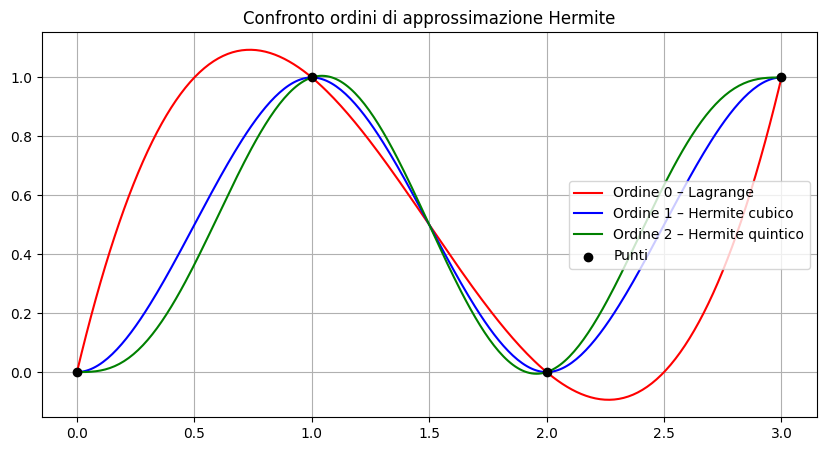

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicHermiteSpline, lagrange, make_interp_spline

x = np.array([0, 1, 2, 3], dtype=float)
y = np.array([0, 1, 0, 1], dtype=float)

dy  = np.zeros_like(x)
ddy = np.zeros_like(x)

# Ordine 0: solo valori (Lagrange)
lag = lagrange(x, y)

# Ordine 1: valori + y'
h1 = CubicHermiteSpline(x, y, dy)

# Ordine 2: valori + y' + y''
# bc_type vuole coppie (ordine_derivata, valore) SOLO agli estremi sinistro e destro
bc_left  = [(1, dy[0]),  (2, ddy[0])]   # condizioni in x[0]
bc_right = [(1, dy[-1]), (2, ddy[-1])]  # condizioni in x[-1]

h2 = make_interp_spline(x, y, k=5, bc_type=(bc_left, bc_right))

x_fine = np.linspace(0, 3, 300)

plt.figure(figsize=(10, 5))
plt.plot(x_fine, lag(x_fine), 'r-', label='Ordine 0 – Lagrange')
plt.plot(x_fine, h1(x_fine), 'b-', label='Ordine 1 – Hermite cubico')
plt.plot(x_fine, h2(x_fine), 'g-', label='Ordine 2 – Hermite quintico')
plt.scatter(x, y, color='black', zorder=5, label='Punti')
plt.legend()
plt.grid(True)
plt.title('Confronto ordini di approssimazione Hermite')
plt.show()